In [15]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [16]:
data = "C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/8 28th Random Forest Project 9  10/10. Random Forests/Company_Data.csv"
df = pd.read_csv(data)
df.head(5)

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


In [17]:
df.shape

(400, 11)

In [18]:
df.columns

Index(['Sales', 'CompPrice', 'Income', 'Advertising', 'Population', 'Price',
       'ShelveLoc', 'Age', 'Education', 'Urban', 'US'],
      dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sales        400 non-null    float64
 1   CompPrice    400 non-null    int64  
 2   Income       400 non-null    int64  
 3   Advertising  400 non-null    int64  
 4   Population   400 non-null    int64  
 5   Price        400 non-null    int64  
 6   ShelveLoc    400 non-null    object 
 7   Age          400 non-null    int64  
 8   Education    400 non-null    int64  
 9   Urban        400 non-null    object 
 10  US           400 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 34.5+ KB


In [20]:
df.describe()

,Sales,CompPrice,Income,Advertising,Population,Price,Age,Education
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000
mean,7.496325,124.975000,68.657500,6.635000,264.840000,115.795000,53.322500,13.900000
std,2.824115,15.334512,27.986037,6.650364,147.376436,23.676664,16.200297,2.620528
min,0.000000,77.000000,21.000000,0.000000,10.000000,24.000000,25.000000,10.000000
25%,5.390000,115.000000,42.750000,0.000000,139.000000,100.000000,39.750000,12.000000
50%,7.490000,125.000000,69.000000,5.000000,272.000000,117.000000,54.500000,14.000000
75%,9.320000,135.000000,91.000000,12.000000,398.500000,131.000000,66.000000,16.000000
max,16.270000,175.000000,120.000000,29.000000,509.000000,191.000000,80.000000,18.000000


In [21]:
df.isnull().sum()

Sales          0
CompPrice      0
Income         0
Advertising    0
Population     0
Price          0
ShelveLoc      0
Age            0
Education      0
Urban          0
US             0
dtype: int64

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
df['ShelveLoc'] = df['ShelveLoc'].map({'Good':2, 'Medium':1,'Bad':0})
df['Urban'] = df['Urban'].map({'Yes':1, 'No':0})
df['US'] = df['US'].map({'Yes':1, 'No':0})

In [24]:
df.head(8)

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,0,42,17,1,1
1,11.22,111,48,16,260,83,2,65,10,1,1
2,10.06,113,35,10,269,80,1,59,12,1,1
3,7.40,117,100,4,466,97,1,55,14,1,1
4,4.15,141,64,3,340,128,0,38,13,1,0
5,10.81,124,113,13,501,72,0,78,16,0,1
6,6.63,115,105,0,45,108,1,71,15,1,0
7,11.85,136,81,15,425,120,2,67,10,1,1


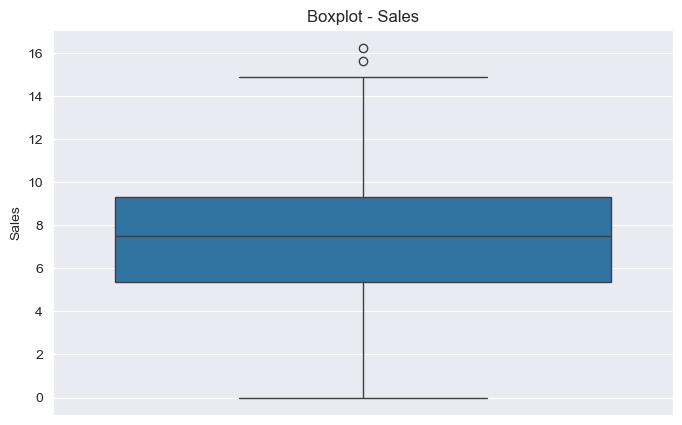

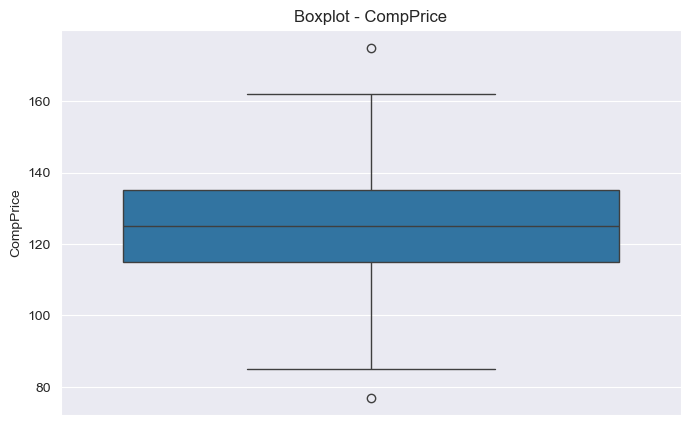

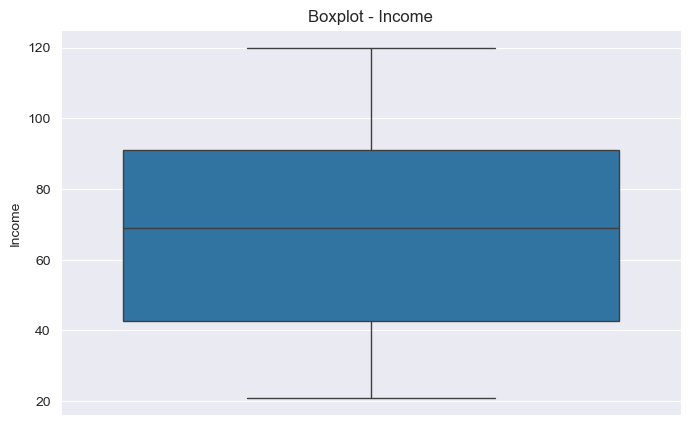

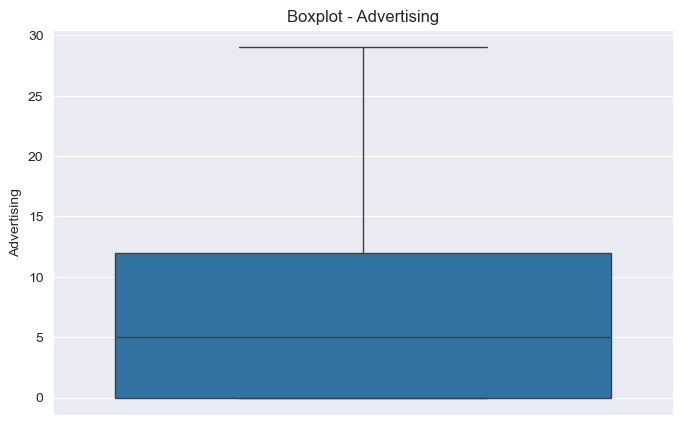

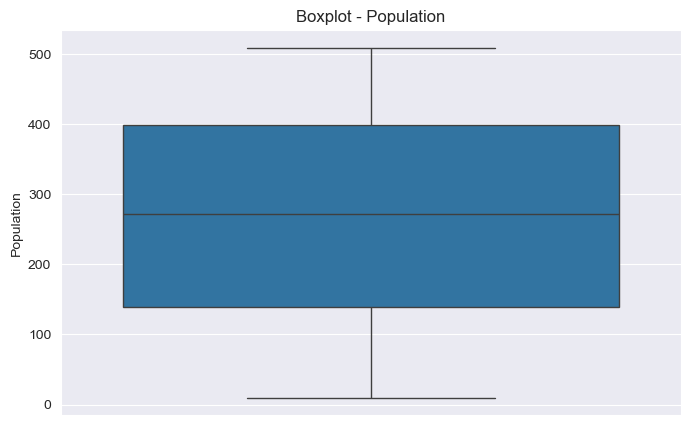

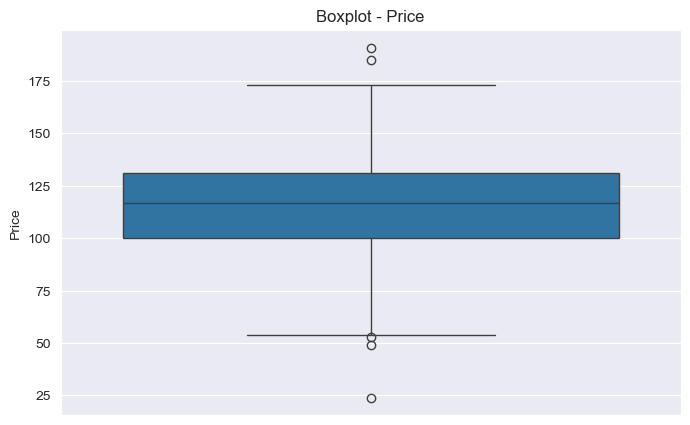

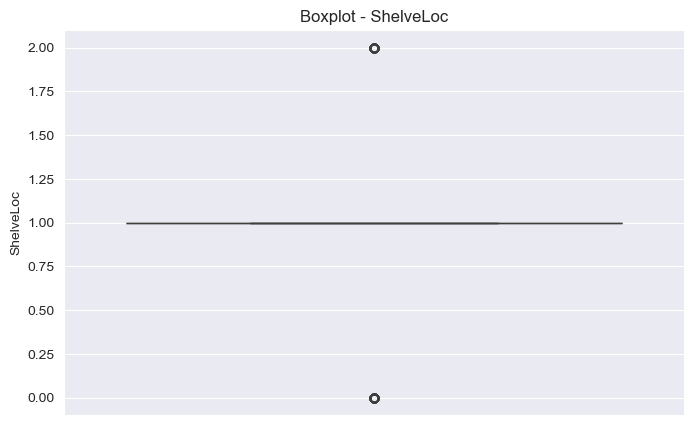

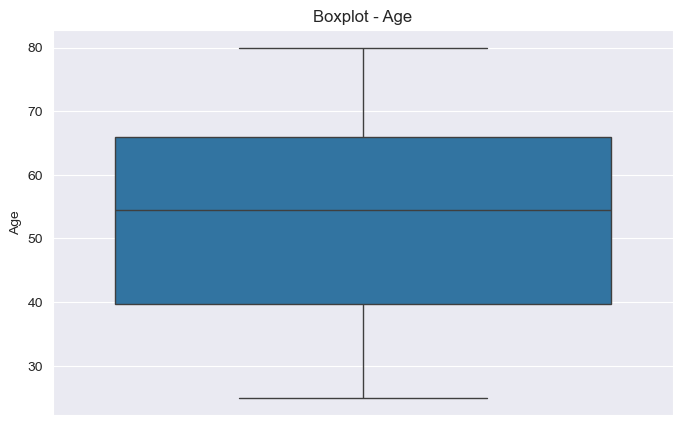

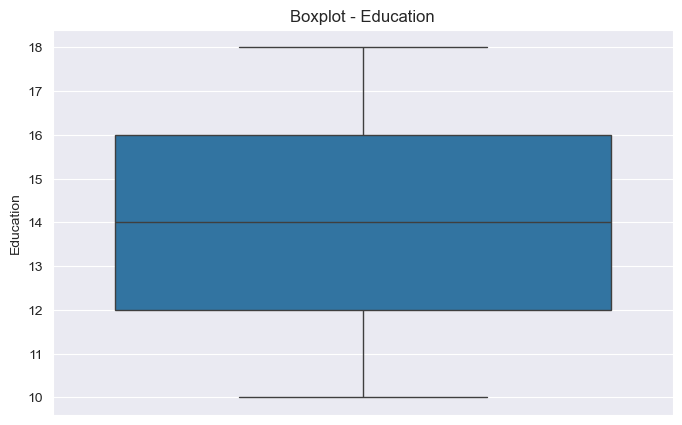

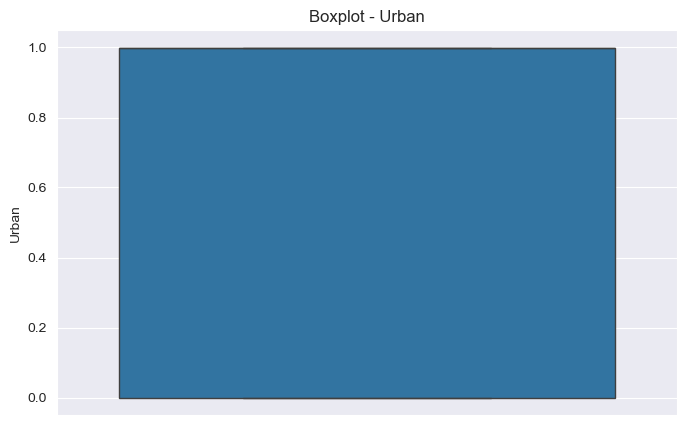

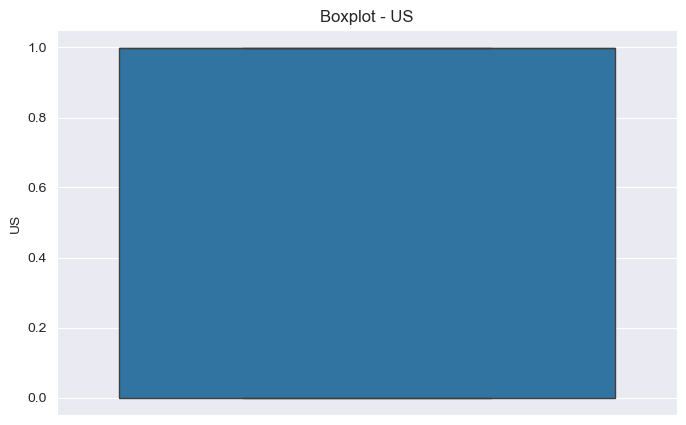

In [37]:
for i in df.columns: 
    sns.set_style('darkgrid')
    plt.figure(figsize=(8,5))
    sns.boxplot(data = df[i])
    plt.title(f"Boxplot - {i}")
    plt.savefig(f"C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/8 28th Random Forest Project 9  10/10. Random Forests/Company Data graphs/Boxplot{i}.png")
    plt.show()

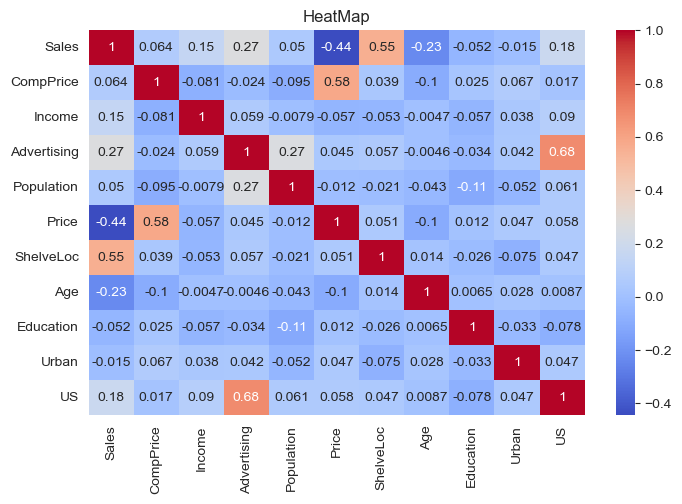

In [29]:
sns.set_style('darkgrid')
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(), annot = True, cmap ='coolwarm')
plt.title("HeatMap")
plt.savefig("C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/8 28th Random Forest Project 9  10/10. Random Forests/Company Data graphs/HeatMap.png")
plt.show()

<Figure size 800x800 with 0 Axes>

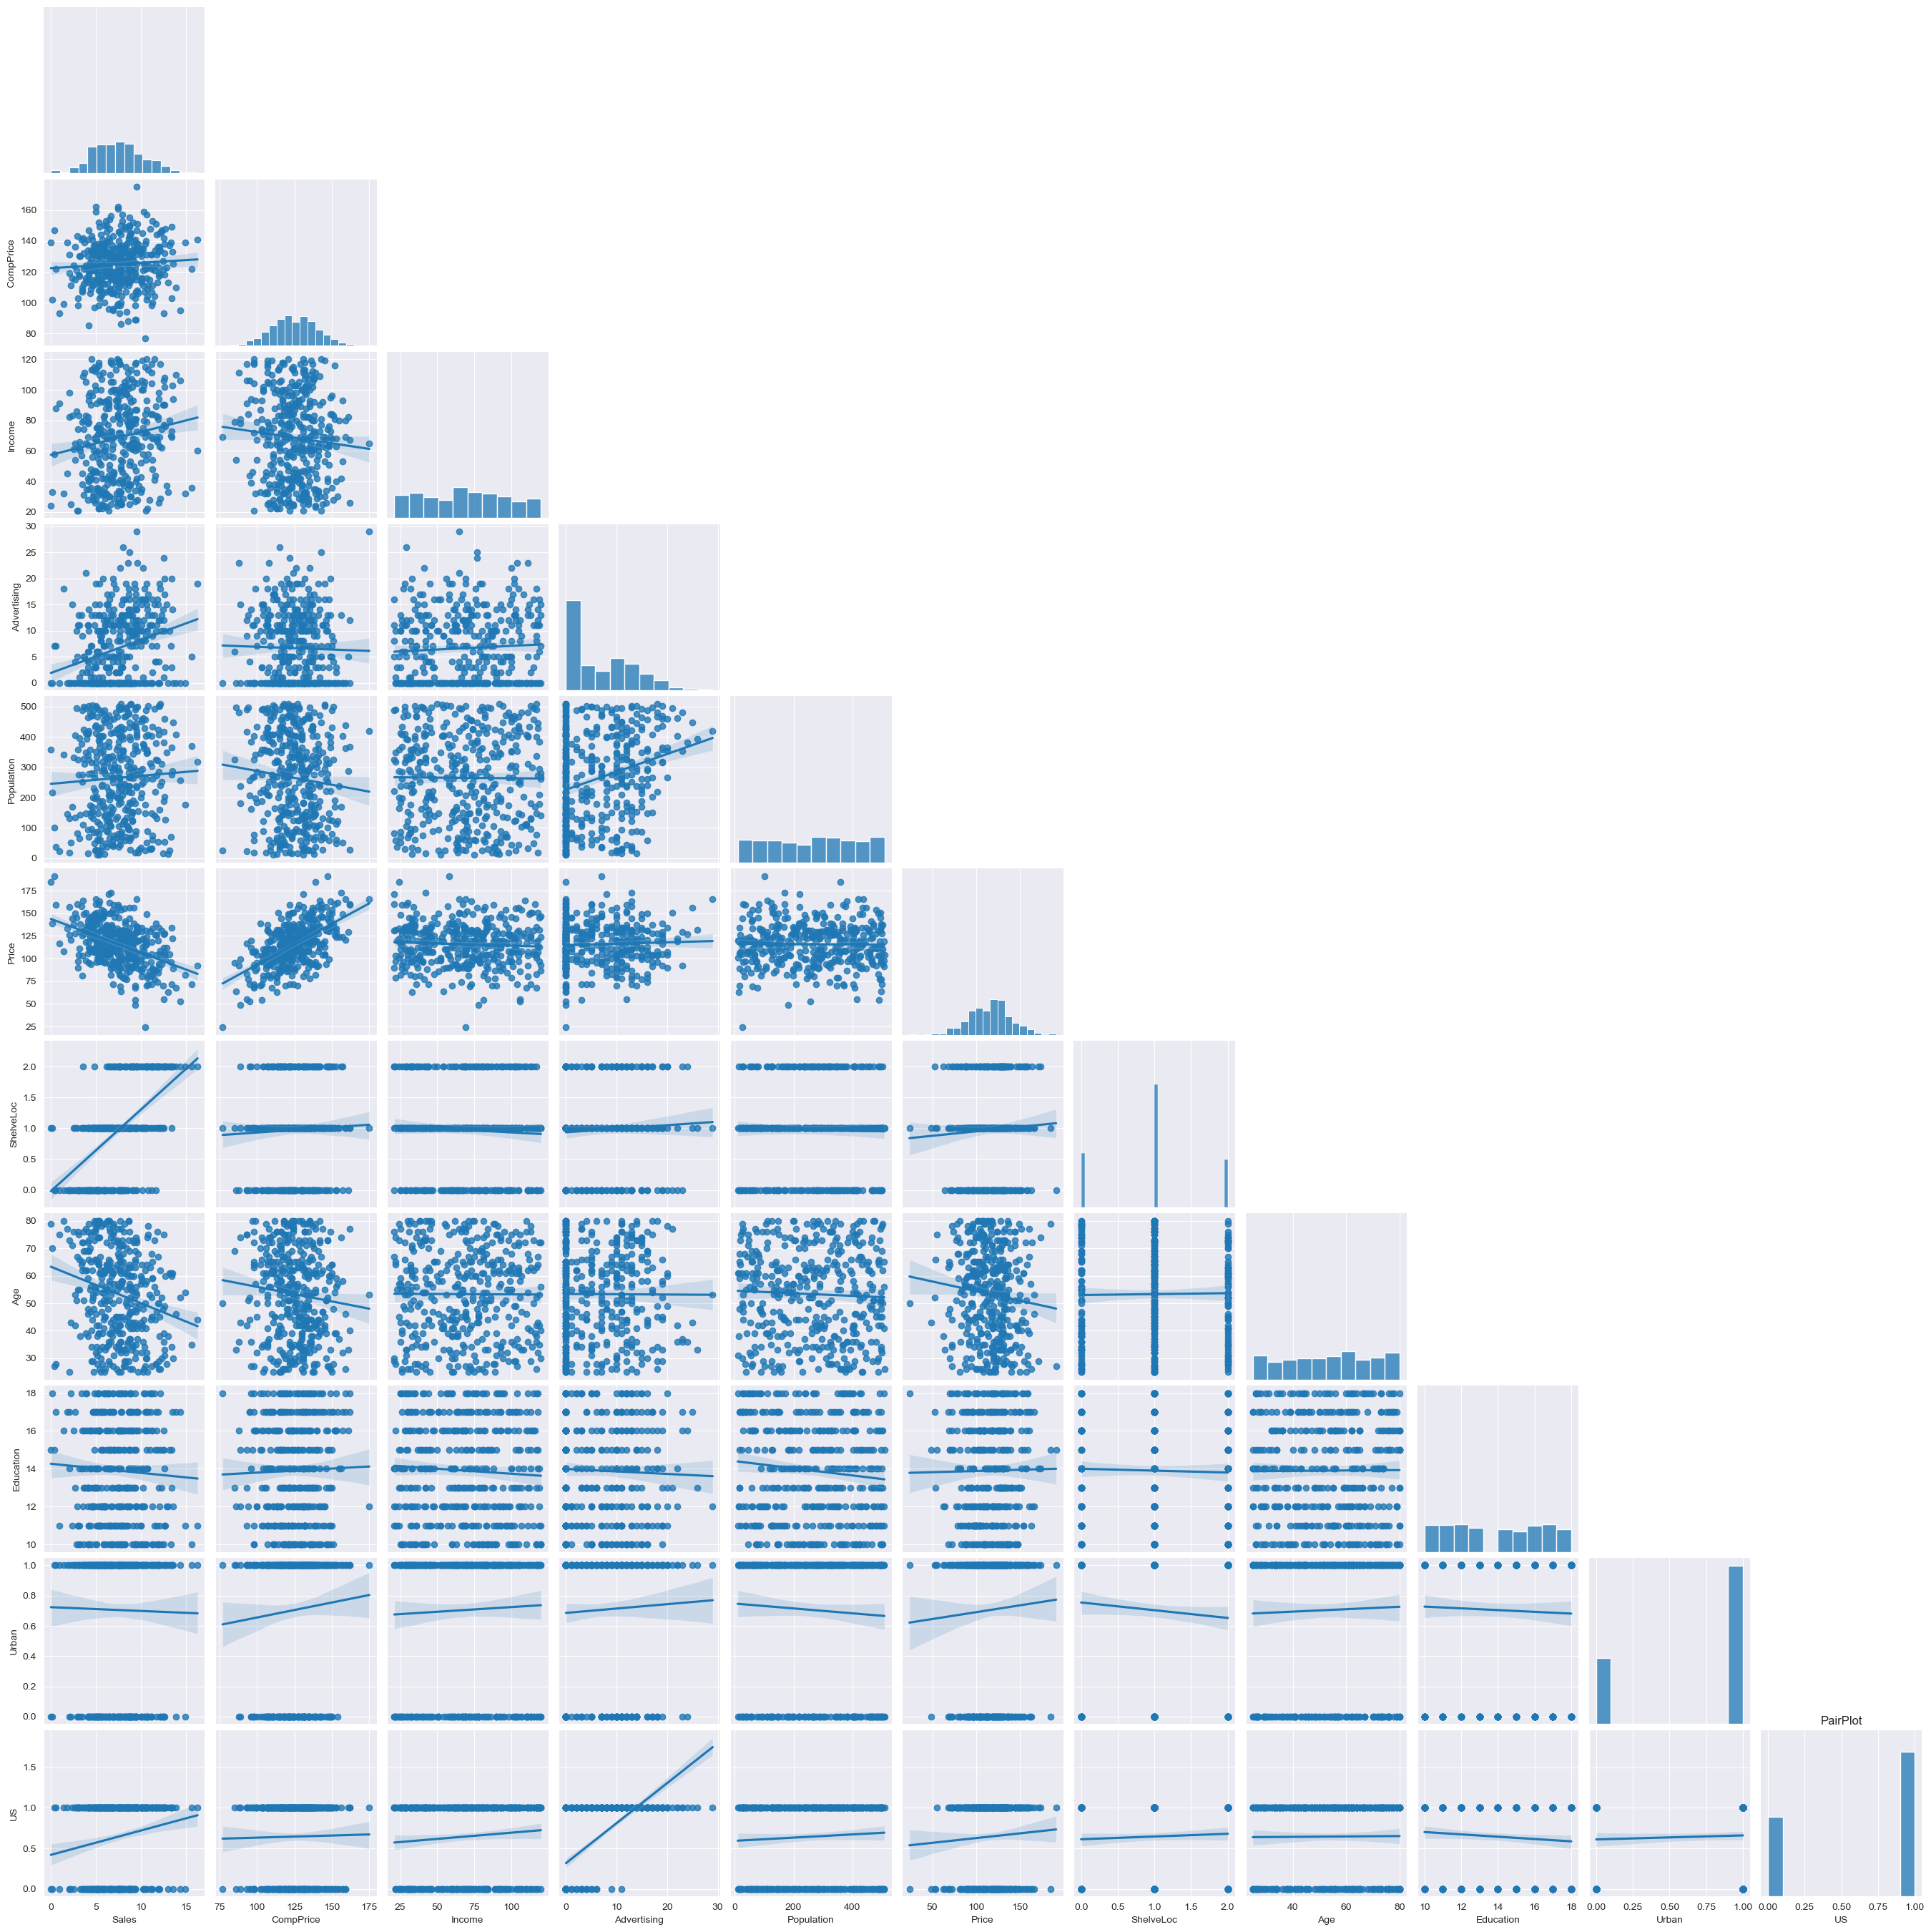

In [38]:
sns.set_style('darkgrid')
plt.figure(figsize=(8,8))
sns.pairplot(data = df , kind ='reg',corner=True)
plt.title("PairPlot")
plt.savefig("C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/8 28th Random Forest Project 9  10/10. Random Forests/Company Data graphs/PairPlot.png")
plt.show()

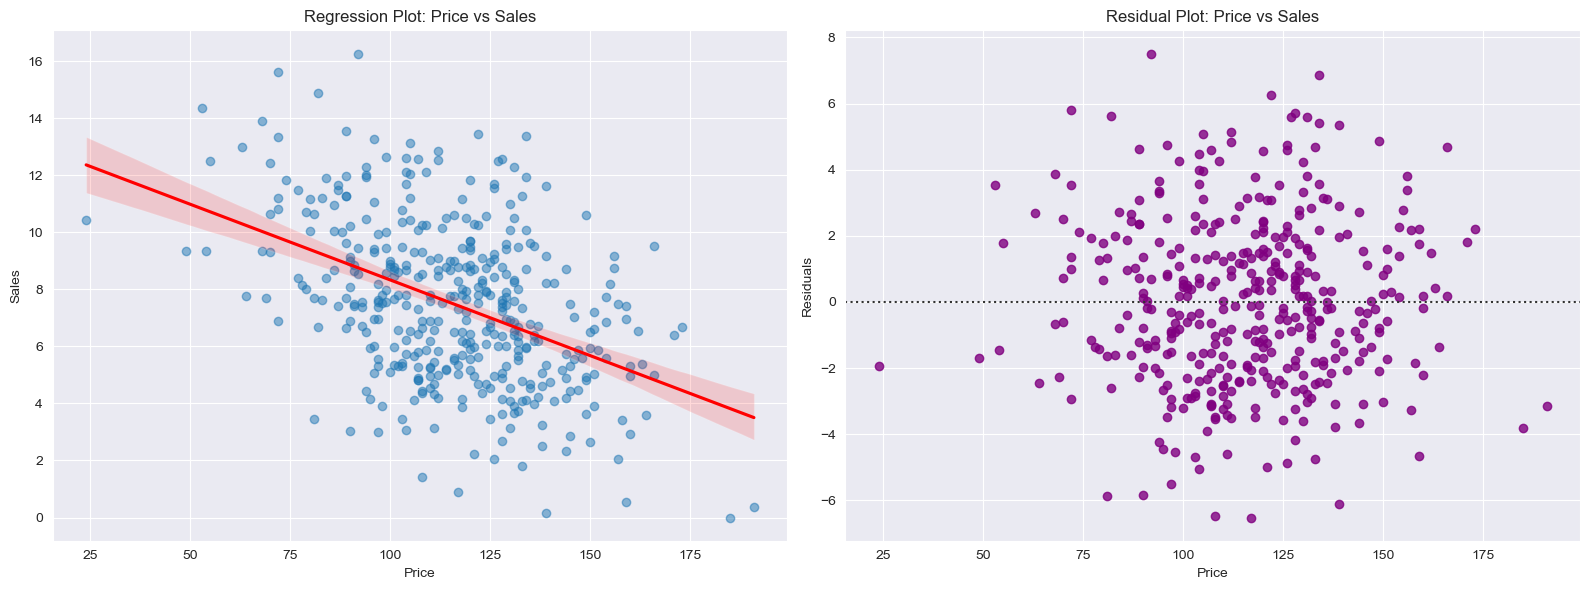

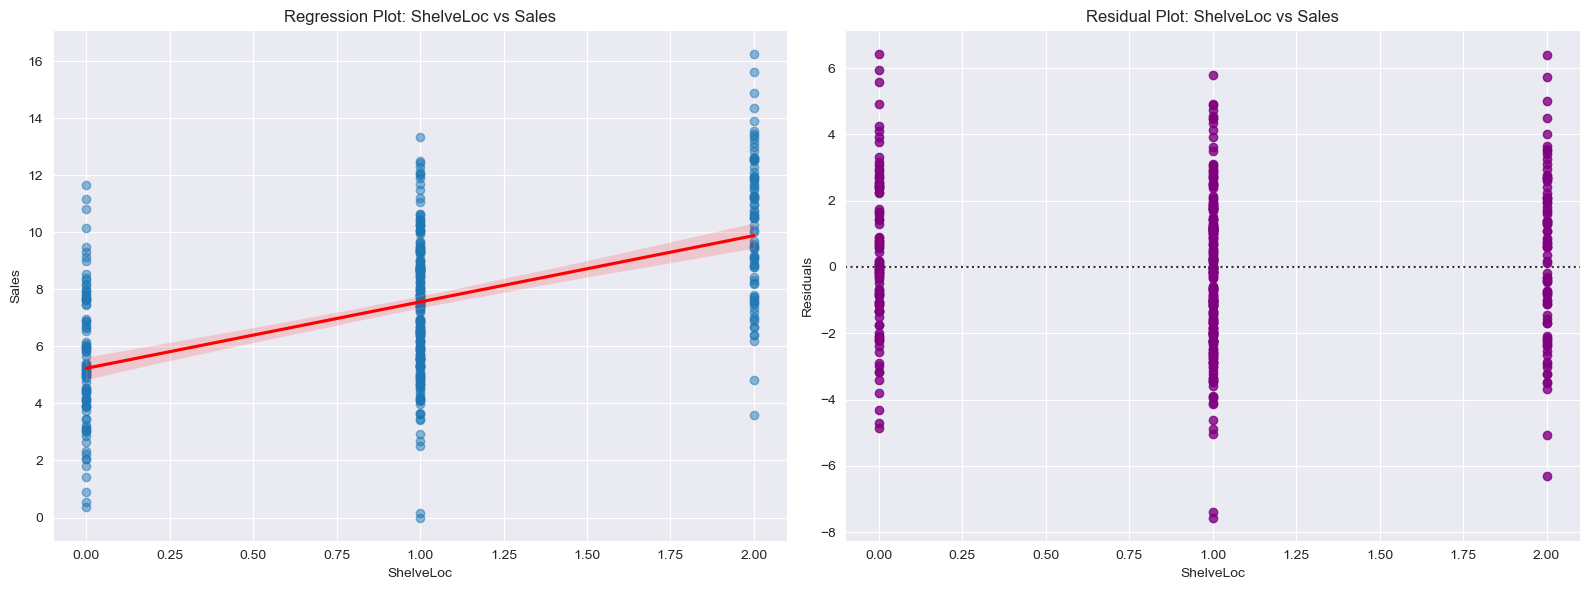

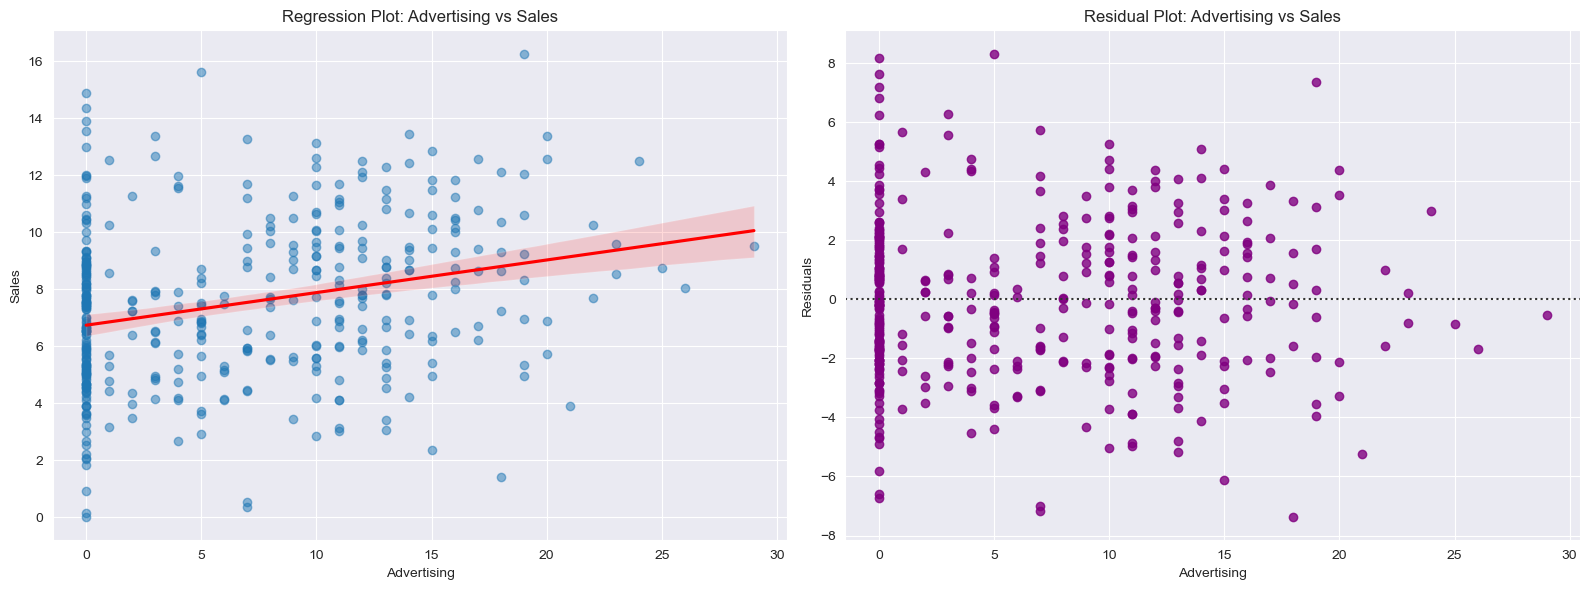

In [39]:
features = ['Price', 'ShelveLoc', 'Advertising']

for feature in features:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # 1. Regression Plot
    sns.regplot(data=df, x=feature, y='Sales', ax=ax1, 
                scatter_kws={'alpha':0.5}, line_kws={"color": "red"})
    ax1.set_title(f'Regression Plot: {feature} vs Sales')
    ax1.set_xlabel(feature)
    ax1.set_ylabel('Sales')
    plt.savefig(f"C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/8 28th Random Forest Project 9  10/10. Random Forests/Company Data graphs/Regression Plot{feature}.png")

    
    # 2. Residual Plot
    # Shows the distance between the data points and the regression line
    sns.residplot(data=df, x=feature, y='Sales', ax=ax2, color="purple")
    ax2.set_title(f'Residual Plot: {feature} vs Sales')
    ax2.set_xlabel(feature)
    ax2.set_ylabel('Residuals')
    
    plt.tight_layout()
    plt.savefig(f"C:/Users/Lenovo/Desktop/Top Mentor/Assignment/need to do/8 28th Random Forest Project 9  10/10. Random Forests/Company Data graphs/Regression Plot{feature}.png")
    plt.show()

Model Accuracy: 87.50%

Detailed Performance Report:
              precision    recall  f1-score   support

        High       0.88      0.88      0.88        43
         Low       0.86      0.86      0.86        37

    accuracy                           0.88        80
   macro avg       0.87      0.87      0.87        80
weighted avg       0.88      0.88      0.88        80



C:\Users\Lenovo\AppData\Local\Temp\ipykernel_10780\1403863829.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances, y=importances.index, palette='viridis')


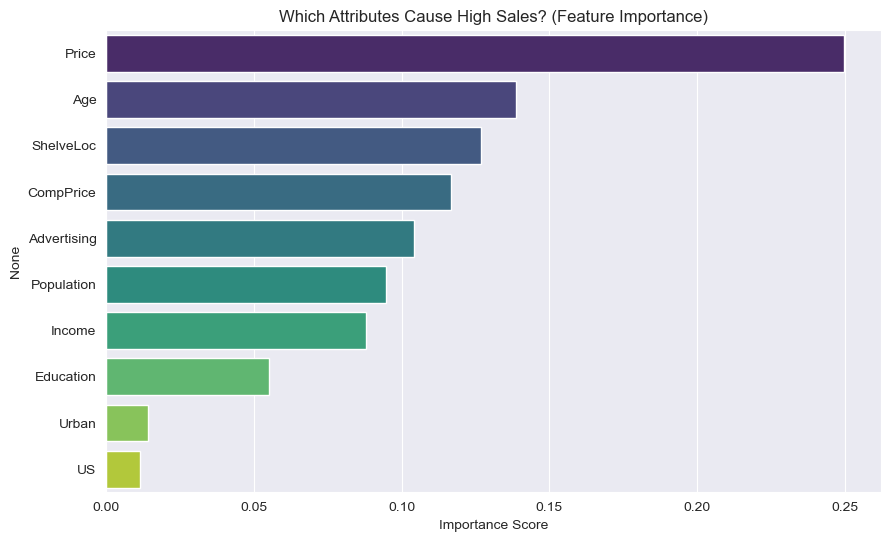

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


# 1. Convert Sales to a Categorical Variable
# We define 'High Sales' as anything above the median value
sales_median = df['Sales'].median()
df['Sales_Status'] = df['Sales'].apply(lambda x: 'High' if x > sales_median else 'Low')

# 2. Define Features and Target
# We exclude the original 'Sales' and the new 'Sales_Status' from our features
X = df.drop(['Sales', 'Sales_Status'], axis=1)
y = df['Sales_Status']

# 3. Split the data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Random Forest
# n_estimators=100 is a standard starting point for the number of trees
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Predict and Evaluate
y_pred = rf_model.predict(X_test)

print(f"Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Performance Report:")
print(classification_report(y_test, y_pred))

# 6. Feature Importance (The "Why" behind the sales)
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances, y=importances.index, palette='viridis')
plt.title('Which Attributes Cause High Sales? (Feature Importance)')
plt.xlabel('Importance Score')
plt.show()